# COVID-19 Hospitalization Surge Forecasting
### Hybrid SEIR + Statistical Correction Model
County-level forecast with 90% prediction intervals · 1–4 week ahead

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

print('Imports successful.')

Imports successful.


In [112]:
# Configuration
TARGET_FIPS = '48113'
TARGET_COUNTY = 'Dallas County, TX'
COUNTY_POPULATION = 2613539

# SEIR parameters (per week)
SIGMA = 1 / 5.1  # incubation rate
GAMMA = 1 / 10   # recovery rate

# Model tuning
VAX_EFFECTIVENESS = 0.85  # vaccination effectiveness reduction
VAX_RATE = 0.62
CI_Z = 1.645  # 90% confidence interval z-score

# Data split
HOLDOUT_FRACTION = 0.20

WAVE_PERIODS = [
  ('2020-07-01','2021-03-01'),
  ('2021-03-01','2021-10-01'),
  ('2021-10-01','2022-04-01'),
  ('2022-04-01','2024-12-31'),
]

def effective_beta(beta_raw, vax_rate):
    """Calculate effective beta accounting for vaccination rate"""
    return beta_raw * (1 - VAX_EFFECTIVENESS * vax_rate)

print(f'Target: {TARGET_COUNTY}, Population: {COUNTY_POPULATION:,}')

Target: Dallas County, TX, Population: 2,613,539


In [113]:
# Load data
FILE_PATH = r'/content/anag-cw7u.csv'
df = pd.read_csv(FILE_PATH, low_memory=False)

print(f'Loaded {len(df):,} rows')
print(f'Columns: {df.shape[1]} available')


Loaded 92,347 rows
Columns: 128 available


In [114]:
# Save a copy before we filter to Dallas only
# We need this later to run the model on other counties
df_raw = df.copy()
df_raw.columns = df_raw.columns.str.strip().str.lower()
df_raw = df_raw.dropna(subset=['fips_code'])
df_raw['fips_code'] = df_raw['fips_code'].astype(float).astype(int).astype(str).str.zfill(5)

In [115]:
print('Shape at start of clean cell:', df.shape)

df.columns = df.columns.str.strip().str.lower()

# Drop NaN fips FIRST, then convert
df = df.dropna(subset=['fips_code'])
df['fips_code'] = df['fips_code'].astype(float).astype(int).astype(str).str.zfill(5)
print(df['fips_code'].unique()[:20])
print(df['state'].unique()[:10])

# Filter to target county
df = df[df['fips_code'] == TARGET_FIPS].copy()
print(f'Rows for FIPS {TARGET_FIPS}: {len(df)}')

# Check date values
print('Sample collection_week values:', df['collection_week'].dropna().unique()[:5])

# Parse date
df['date'] = pd.to_datetime(df['collection_week'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce')
print(f'NaT count: {df["date"].isna().sum()} of {len(df)}')

# Hospitalization column
hosp_col = 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg'
df[hosp_col] = pd.to_numeric(df[hosp_col], errors='coerce')

# Drop missing
df = df.dropna(subset=['date', hosp_col])
df = df[df[hosp_col] > 0]
df = df[df[hosp_col] < 500000]
df = df.sort_values('date')

print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Hospitalizations: {df[hosp_col].min():.0f} – {df[hosp_col].max():.0f}')

Shape at start of clean cell: (92347, 128)
['48201' '48085' '48037' '48099' '48071' '48057' '48503' '48215' '48371'
 '48113' '48141' '48245' '48075' '48481' '48475' '48469' '48321' '48025'
 '48121' '48357']
['TX']
Rows for FIPS 48113: 6469
Sample collection_week values: ['2021-04-04T00:00:00.000' '2022-07-31T00:00:00.000'
 '2022-02-27T00:00:00.000' '2022-11-20T00:00:00.000'
 '2022-11-13T00:00:00.000']
NaT count: 0 of 6469
Date range: 2020-07-12 to 2024-04-21
Hospitalizations: 4 – 314


In [116]:
# Aggregate across hospitals to get county-level weekly total
weekly = df.groupby('date')[hosp_col].sum()
weekly = weekly[weekly > 0]
weekly_df = pd.DataFrame({'date': weekly.index, 'hosp': weekly.values}).reset_index(drop=True)

print(f'Weekly data points: {len(weekly_df)}')
print(f'Average hospitalizations: {weekly_df["hosp"].mean():.0f}')

Weekly data points: 198
Average hospitalizations: 351


In [98]:
# Fetch CDC vaccination and case data
try:
    url = f'https://data.cdc.gov/resource/8xkx-amqh.json?fips={TARGET_FIPS}&$limit=50000&$order=date%20ASC'
    response = requests.get(url).json()

    if not isinstance(response, list) or len(response) == 0:
        raise ValueError("Empty or unexpected API response")

    data = pd.DataFrame(response)

    if 'date' not in data.columns or 'series_complete_pop_pct' not in data.columns:
        raise ValueError(f"Missing columns. Got: {list(data.columns)}")

    data['date'] = pd.to_datetime(data['date']).dt.normalize()  # strip time component
    data['vax_rate'] = pd.to_numeric(data['series_complete_pop_pct'], errors='coerce') / 100
    data = data.dropna(subset=['date', 'vax_rate'])

    vax_weekly = data[['date', 'vax_rate']].drop_duplicates('date').sort_values('date').reset_index(drop=True)
    vax_weekly['vax_rate'] = vax_weekly['vax_rate'].ffill()

    print(f'Vaccination: {len(vax_weekly)} weeks, latest: {vax_weekly["vax_rate"].iloc[-1]:.2f}')

except Exception as e:
    print(f'Vaccination error: {e}')
    vax_weekly = pd.DataFrame({'date': pd.Series(dtype='datetime64[ns]'), 'vax_rate': pd.Series(dtype='float64')})

try:
    url = 'https://data.cdc.gov/resource/pwn4-m3yp.json?state=TX&$limit=500&$order=date_updated%20ASC'
    response = requests.get(url).json()

    if not isinstance(response, list) or len(response) == 0:
        raise ValueError("Empty or unexpected API response")

    data = pd.DataFrame(response)
    data['date'] = pd.to_datetime(data['date_updated']).dt.normalize()
    data['new_cases'] = pd.to_numeric(data['new_cases'], errors='coerce')
    cases_df = data[['date', 'new_cases']].dropna().reset_index(drop=True)

    print(f'Cases: {len(cases_df)} rows, {cases_df["date"].min().date()} to {cases_df["date"].max().date()}')

except Exception as e:
    print(f'Cases error: {e}')
    cases_df = pd.DataFrame(columns=['date', 'new_cases'])

# Normalize weekly_df dates before merging
weekly_df['date'] = pd.to_datetime(weekly_df['date']).dt.normalize()

# Merge vaccination data
if len(vax_weekly) > 0:
    weekly_df = weekly_df.merge(vax_weekly, on='date', how='left')
    weekly_df['vax_rate'] = weekly_df['vax_rate'].ffill().fillna(VAX_RATE)
else:
    weekly_df['vax_rate'] = VAX_RATE

print(f'Vax rate range: {weekly_df["vax_rate"].min():.2f} – {weekly_df["vax_rate"].max():.2f}')

# Add cases column whether or not API succeeded
if 'new_cases' not in weekly_df.columns:
    weekly_df['new_cases'] = 0

Vaccination: 598 weeks, latest: 0.62
Cases: 173 rows, 2020-01-23 to 2023-05-11
Vax rate range: 0.00 – 0.62


In [99]:
# Simple SEIR model
def seir_step(S, E, I, R, beta, sigma, gamma, N):
    """One week of SEIR dynamics"""
    new_exposed = beta * S * I / N
    new_infected = sigma * E
    new_recovered = gamma * I

    S = S - new_exposed
    E = E + new_exposed - new_infected
    I = I + new_infected - new_recovered
    R = R + new_recovered

    return max(S, 0), max(E, 0), max(I, 0), max(R, 0)

def seir_forecast(beta, sigma, gamma, S0, E0, I0, R0, weeks):
    """Forecast I (infectious) for given weeks"""
    N = S0 + E0 + I0 + R0
    S, E, I, R = S0, E0, I0, R0
    I_path = []

    for _ in range(weeks):
        S, E, I, R = seir_step(S, E, I, R, beta, sigma, gamma, N)
        I_path.append(I)

    return np.array(I_path)

print('SEIR model defined.')

SEIR model defined.


In [100]:
weekly_df['growth_rate'] = weekly_df['hosp'].pct_change().fillna(0)
weekly_df['hosp_lag2'] = weekly_df['hosp'].shift(2).fillna(0)
weekly_df['hosp_lag3'] = weekly_df['hosp'].shift(3).fillna(0)
weekly_df['wave_id'] = 0
for i,(start,end) in enumerate(WAVE_PERIODS):
  mask = (weekly_df['date']>=start)&(weekly_df['date']<end)
  weekly_df.loc[mask,'wave_id'] = i
print(weekly_df[['date','hosp','growth_rate','wave_id']].tail())

          date  hosp  growth_rate  wave_id
193 2024-03-24  21.4    -0.173745        3
194 2024-03-31  18.0    -0.158879        3
195 2024-04-07  21.3     0.183333        3
196 2024-04-14  20.7    -0.028169        3
197 2024-04-21  17.3    -0.164251        3


In [101]:
from scipy.optimize import minimize_scalar
# Train/test split
y = weekly_df['hosp'].values
n_total = len(y)
n_hold = max(4, int(n_total * HOLDOUT_FRACTION))
n_train = n_total - n_hold

y_train = y[:n_train]
y_hold  = y[n_train:]

# Capacity threshold
recent_y = y[-52:]
HOSPITAL_CAPACITY = int(np.percentile(recent_y, 75))
print(f'Capacity threshold (recent 75th pct): {HOSPITAL_CAPACITY:,}')

# Global SEIR initial conditions (used by wave loop below)
I0 = float(y_train[0])
E0 = I0 * (SIGMA / (SIGMA + GAMMA))
S0 = COUNTY_POPULATION - E0 - I0
R0 = 0.0


wave_betas = {}
wave_scales = {}

for i, (start, end) in enumerate(WAVE_PERIODS):
    mask = (weekly_df['date'] >= start) & (weekly_df['date'] < end)
    wdf = weekly_df[mask]
    if len(wdf) < 4:
        continue
    vr = wdf['vax_rate'].mean()
    yw = wdf['hosp'].values
    I0_w = float(yw[0])
    E0_w = I0_w * (SIGMA / (SIGMA + GAMMA))
    S0_w = COUNTY_POPULATION - E0_w - I0_w

    def bmae(b, vr=vr, yw=yw, I0_w=I0_w, E0_w=E0_w, S0_w=S0_w):
        beta_eff = effective_beta(b, vr)
        I_pred = seir_forecast(beta_eff, SIGMA, GAMMA, S0_w, E0_w, I0_w, 0.0, len(yw))
        scale = yw.mean() / (I_pred.mean() + 1e-9)
        return np.mean(np.abs(I_pred * scale - yw))

    res = minimize_scalar(bmae, bounds=(0.05, 2.0), method='bounded')
    beta_eff = effective_beta(res.x, vr)
    I_pred = seir_forecast(beta_eff, SIGMA, GAMMA, S0_w, E0_w, I0_w, 0.0, len(yw))
    wave_scales[i] = yw.mean() / (I_pred.mean() + 1e-9)
    wave_betas[i] = beta_eff

# Fall back to last wave's beta for forecasting
best_beta = wave_betas[max(wave_betas)]
best_scale = wave_scales[max(wave_scales)]

# Recompute full-series SEIR prediction using per-wave betas
I_all_pred_list = []
for idx in range(len(y)):
    row_wave = weekly_df['wave_id'].iloc[idx]
    beta_w = wave_betas.get(row_wave, best_beta)
    scale_w = wave_scales.get(row_wave, best_scale)
    I0_t = float(y[idx])
    E0_t = I0_t * (SIGMA / (SIGMA + GAMMA))
    S0_t = COUNTY_POPULATION - E0_t - I0_t
    I_step = seir_forecast(beta_w, SIGMA, GAMMA, S0_t, E0_t, I0_t, 0.0, 1)
    I_all_pred_list.append(I_step[0] * scale_w)

I_all_pred = np.array(I_all_pred_list)

print('Per-wave betas:', {k: round(v, 4) for k, v in wave_betas.items()})
print(f'Forecast beta (latest wave): {best_beta:.4f}')

Capacity threshold (recent 75th pct): 35
Per-wave betas: {0: np.float64(0.1384), 1: np.float64(0.2738), 2: np.float64(0.1054), 3: np.float64(0.9637)}
Forecast beta (latest wave): 0.9637


In [102]:
# Train on all data to get SEIR predictions
seir_pred_train = I_all_pred[:n_train]
residuals = y_train - seir_pred_train

# Add lagged cases as extra feature if available
cases_lag1 = weekly_df['new_cases'].shift(1).fillna(0).values

X_train = np.column_stack([
  seir_pred_train,
  cases_lag1[:n_train],
  weekly_df['growth_rate'].values[:n_train],
  weekly_df['hosp_lag2'].values[:n_train],
  weekly_df['hosp_lag3'].values[:n_train],
])
corrector = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
corrector.fit(X_train, residuals)


correction_train = corrector.predict(X_train).flatten()
y_corrected_train = np.clip(seir_pred_train + correction_train, 0, None)
residual_std = np.std(residuals - correction_train)

mae_base = np.mean(np.abs(seir_pred_train - y_train))
mae_corr = np.mean(np.abs(y_corrected_train - y_train))

print(f'Training MAE (SEIR): {mae_base:.1f}, MAE (corrected): {mae_corr:.1f}')

Training MAE (SEIR): 162.8, MAE (corrected): 10.4


In [103]:
# Evaluate on holdout set
seir_pred_hold = I_all_pred[n_train:n_train+n_hold]
X_hold = np.column_stack([
    seir_pred_hold,
    cases_lag1[n_train:n_train+n_hold],
    weekly_df['growth_rate'].values[n_train:n_train+n_hold],
    weekly_df['hosp_lag2'].values[n_train:n_train+n_hold],
    weekly_df['hosp_lag3'].values[n_train:n_train+n_hold],
])

corr_hold = corrector.predict(X_hold).flatten()
y_corrected_hold = np.clip(seir_pred_hold + corr_hold, 0, None)

# Confidence intervals
lower_hold = np.clip(y_corrected_hold - CI_Z * residual_std, 0, None)
upper_hold = y_corrected_hold + CI_Z * residual_std

mae_base_hold = np.mean(np.abs(seir_pred_hold - y_hold))
mae_corr_hold = np.mean(np.abs(y_corrected_hold - y_hold))
coverage = np.mean((y_hold >= lower_hold) & (y_hold <= upper_hold)) * 100

print(f'\n=== HOLDOUT EVALUATION ===')
print(f'MAE (SEIR):      {mae_base_hold:.1f} beds')
print(f'MAE (corrected): {mae_corr_hold:.1f} beds')
print(f'90% CI coverage: {coverage:.1f}%')

# ---------------------------------------------------
# Multi-county evaluation
# Run the same simple model on two more Texas counties
# and compare MAE and coverage in a table
# ---------------------------------------------------

hosp_col = 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_avg'

# Counties to compare: Dallas, Harris (Houston), Bexar (San Antonio)
counties = {'48201': 'Harris', '48029': 'Bexar'}
county_results = []

dallas_mae = mae_corr_hold
dallas_cov = coverage

for fips, name in counties.items():

    # Get this county's weekly data
    c = df_raw[df_raw['fips_code'] == fips].copy()
    c['date'] = pd.to_datetime(c['collection_week'], errors='coerce').dt.normalize()
    c[hosp_col] = pd.to_numeric(c[hosp_col], errors='coerce')
    c = c.dropna(subset=['date', hosp_col])
    c = c[c[hosp_col] > 0]
    wc = c.groupby('date')[hosp_col].sum().reset_index()
    wc.columns = ['date', 'hosp']
    wc = wc.sort_values('date').reset_index(drop=True)

    if len(wc) < 20:
        print(f'Skipping {name} - not enough data')
        continue

    yc = wc['hosp'].values
    nc_hold = max(4, int(len(yc) * 0.20))
    nc_train = len(yc) - nc_hold
    yc_train = yc[:nc_train]
    yc_hold  = yc[nc_train:]

    pop_lookup = {'48201': 4731145, '48029': 2009324}
    county_pop = pop_lookup.get(fips, COUNTY_POPULATION)

    I0c = float(yc_train[0])
    E0c = I0c * (SIGMA / (SIGMA + GAMMA))
    S0c = county_pop - E0c - I0c



    def bmae_c(b):
        pred = seir_forecast(effective_beta(b, VAX_RATE), SIGMA, GAMMA, S0c, E0c, I0c, 0.0, nc_train)
        sc = yc_train.mean() / (pred.mean() + 1e-9)
        return np.mean(np.abs(pred * sc - yc_train))

    res_c = minimize_scalar(bmae_c, bounds=(0.05, 2.0), method='bounded')
    bc = effective_beta(res_c.x, VAX_RATE)
    seir_full = seir_forecast(bc, SIGMA, GAMMA, S0c, E0c, I0c, 0.0, len(yc))
    sc = yc_train.mean() / (seir_full[:nc_train].mean() + 1e-9)
    seir_full = seir_full * sc

    # Same gradient boosting corrector as main Dallas model
    resid_c = yc_train - seir_full[:nc_train]
    wc['growth_rate'] = wc['hosp'].pct_change().fillna(0)
    wc['hosp_lag2'] = wc['hosp'].shift(2).fillna(0)
    wc['hosp_lag3'] = wc['hosp'].shift(3).fillna(0)

    X_train_c = np.column_stack([
        seir_full[:nc_train],
        np.zeros(nc_train),          # no cases data for other counties
        wc['growth_rate'].values[:nc_train],
        wc['hosp_lag2'].values[:nc_train],
        wc['hosp_lag3'].values[:nc_train],
    ])
    X_hold_c = np.column_stack([
        seir_full[nc_train:],
        np.zeros(nc_hold),
        wc['growth_rate'].values[nc_train:],
        wc['hosp_lag2'].values[nc_train:],
        wc['hosp_lag3'].values[nc_train:],
    ])
    gb_c = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    gb_c.fit(X_train_c, resid_c)
    yc_pred = np.clip(seir_full[nc_train:] + gb_c.predict(X_hold_c), 0, None)
    std_c = np.std(resid_c - gb_c.predict(X_train_c))
    mae_c  = np.mean(np.abs(yc_pred - yc_hold))
    cov_c  = np.mean((yc_hold >= yc_pred - CI_Z*std_c) & (yc_hold <= yc_pred + CI_Z*std_c)) * 100

    county_results.append({'County': name, 'MAE (beds)': round(mae_c,1), 'Coverage (%)': round(cov_c,1)})

# Add Dallas result we already computed
county_results.insert(0, {'County': 'Dallas', 'MAE (beds)': round(dallas_mae,1), 'Coverage (%)': round(dallas_cov,1)})

print('\n=== EVALUATION ACROSS COUNTIES ===')
print(pd.DataFrame(county_results).to_string(index=False))

# ---------------------------------------------------
# Rolling time periods evaluation
# Instead of one fixed holdout, slide the cutoff forward
# every 4 weeks and record MAE each time
# ---------------------------------------------------

print('\n=== EVALUATION ACROSS TIME PERIODS (Dallas) ===')
fold_results = []
min_train = int(n_total * 0.5)  # need at least 50% of data to train

for cutoff in range(min_train, n_total - 4, 4):
    yf_tr = y[:cutoff]
    yf_ho = y[cutoff:cutoff+4]

    I0f = float(yf_tr[0])
    E0f = I0f * (SIGMA / (SIGMA + GAMMA))
    S0f = COUNTY_POPULATION - E0f - I0f

    def bmae_f(b):
        pred = seir_forecast(effective_beta(b, VAX_RATE), SIGMA, GAMMA, S0f, E0f, I0f, 0.0, cutoff)
        sc = yf_tr.mean() / (pred.mean() + 1e-9)
        return np.mean(np.abs(pred * sc - yf_tr))

    res_f = minimize_scalar(bmae_f, bounds=(0.05, 2.0), method='bounded')
    bf = effective_beta(res_f.x, VAX_RATE)
    sf = seir_forecast(bf, SIGMA, GAMMA, S0f, E0f, I0f, 0.0, cutoff+4)
    scf = yf_tr.mean() / (sf[:cutoff].mean() + 1e-9)
    sf = sf * scf

    resid_f = yf_tr - sf[:cutoff]
    lrf = LinearRegression().fit(sf[:cutoff].reshape(-1,1), resid_f)
    yf_pred = np.clip(sf[cutoff:] + lrf.predict(sf[cutoff:].reshape(-1,1)), 0, None)

    std_f = np.std(resid_f - lrf.predict(sf[:cutoff].reshape(-1,1)))
    mae_f = np.mean(np.abs(yf_pred - yf_ho))
    cov_f = np.mean((yf_ho >= yf_pred.flatten() - CI_Z*std_f) &
                    (yf_ho <= yf_pred.flatten() + CI_Z*std_f)) * 100

    fold_results.append({
        'Period ending': weekly_df['date'].iloc[cutoff].strftime('%Y-%m'),
        'MAE (beds)': round(mae_f, 1),
        'Coverage (%)': round(cov_f, 1)
    })

print(pd.DataFrame(fold_results).to_string(index=False))


=== HOLDOUT EVALUATION ===
MAE (SEIR):      28.6 beds
MAE (corrected): 5.5 beds
90% CI coverage: 100.0%

=== EVALUATION ACROSS COUNTIES ===
County  MAE (beds)  Coverage (%)
Dallas         5.5         100.0
Harris        20.7         100.0
 Bexar        20.4          82.1

=== EVALUATION ACROSS TIME PERIODS (Dallas) ===
Period ending  MAE (beds)  Coverage (%)
      2022-06       453.0         100.0
      2022-07       288.5         100.0
      2022-07       279.6         100.0
      2022-08       335.7         100.0
      2022-09       399.1         100.0
      2022-10       410.5         100.0
      2022-11       299.7         100.0
      2022-12       171.3         100.0
      2023-01       238.6         100.0
      2023-02       300.4         100.0
      2023-03       327.5         100.0
      2023-04       335.9         100.0
      2023-05       349.8         100.0
      2023-06       366.0         100.0
      2023-07       351.4         100.0
      2023-07       335.7         100.

In [104]:
# Forecast 4 weeks ahead
weeks_ahead = 4

# Start from last observation
I_last = float(y[-1])
E_last = I_last * (SIGMA / (SIGMA + GAMMA))
S_last = COUNTY_POPULATION - E_last - I_last

# Forecast
I_forecast = seir_forecast(best_beta, SIGMA, GAMMA, S_last, E_last, I_last, 0.0, weeks_ahead)
seir_fc = I_forecast * best_scale
last_growth = weekly_df['growth_rate'].values[-1]
last_lag2   = weekly_df['hosp_lag2'].values[-1]
last_lag3   = weekly_df['hosp_lag3'].values[-1]

X_fc = np.column_stack([
    seir_fc,
    np.full(weeks_ahead, cases_lag1[-1]),
    np.full(weeks_ahead, last_growth),
    np.full(weeks_ahead, last_lag2),
    np.full(weeks_ahead, last_lag3),
])

corr_fc = corrector.predict(X_fc).flatten()
fc_point = np.clip(seir_fc + corr_fc, 0, None)
fc_lower = np.clip(fc_point - CI_Z * residual_std * np.sqrt(np.arange(1, weeks_ahead + 1)), 0, None)
fc_upper = fc_point + CI_Z * residual_std * np.sqrt(np.arange(1, weeks_ahead + 1))

# Dates
last_date = weekly_df['date'].iloc[-1]
fc_dates = [last_date + pd.Timedelta(weeks=i+1) for i in range(weeks_ahead)]

print(f'\n=== FORECAST (1-4 weeks ahead) ===')
print(f'{"Week":>6} {"Forecast":>10} {"Lower":>10} {"Upper":>10}')
for i in range(weeks_ahead):
    print(f'{i+1:>6} {fc_point[i]:>10.0f} {fc_lower[i]:>10.0f} {fc_upper[i]:>10.0f}')


=== FORECAST (1-4 weeks ahead) ===
  Week   Forecast      Lower      Upper
     1         23          0         47
     2         23          0         57
     3         26          0         67
     4         26          0         74


In [105]:
# Detect surges (>50% increase over 3 weeks)
print(f'\n=== SURGE DETECTION ===')
print('(Surge = >50% rise over 3 weeks)')

surges = []
for i in range(3, len(y)):
    prev = y[i-3]
    curr = y[i]
    if prev > 0 and (curr - prev) / prev > 0.50:
        surge_date = weekly_df['date'].iloc[i]

        # Look back up to 4 weeks for early signal
        lead_weeks = None
        for lookback in range(1, 5):
            check_i = i - lookback
            if check_i >= 0:
                ratio = y[check_i] / (y[check_i-1] + 1e-9) if check_i > 0 else 1.0
                if ratio > 1.15:  # 15% weekly growth is early signal
                    lead_weeks = lookback
                    break

        surges.append({
            'date': surge_date.date(),
            'rise': f"{(curr-prev)/prev*100:.0f}%",
            'lead': lead_weeks if lead_weeks else '—'
        })

if surges:
    detected = sum(1 for s in surges if isinstance(s['lead'], int))

    # Simple summary table
    surge_df = pd.DataFrame(surges)
    surge_df['lead'] = pd.to_numeric(surge_df['lead'], errors='coerce')

    print(surge_df[['date', 'rise', 'lead']].to_string(index=False))
    print(f'\nTotal surges found:           {len(surges)}')
    print(f'Detected with early warning:  {detected}/{len(surges)}')
    print(f'Average lead time:            {surge_df["lead"].mean():.1f} weeks')
    print(f'Detected >= 1 week early:     {surge_df["lead"].ge(1).sum()}/{len(surges)}')
    print(f'Detected >= 2 weeks early:    {surge_df["lead"].ge(2).sum()}/{len(surges)}')
else:
    print('No surges detected')


=== SURGE DETECTION ===
(Surge = >50% rise over 3 weeks)
      date rise  lead
2020-08-02  72%   2.0
2020-10-25  72%   1.0
2021-07-11  83%   2.0
2021-07-18 109%   1.0
2021-07-25 166%   1.0
2021-08-01 152%   1.0
2021-08-08 147%   1.0
2021-08-15 103%   1.0
2021-08-22  66%   2.0
2021-12-26  80%   NaN
2022-01-02 198%   1.0
2022-01-09 278%   1.0
2022-01-16 156%   1.0
2022-05-29  84%   2.0
2022-06-12  66%   2.0
2022-06-19  68%   1.0
2022-06-26 108%   1.0
2022-07-03  80%   1.0
2022-07-10  68%   2.0
2022-07-17  55%   1.0
2022-07-24  56%   2.0
2022-11-27  95%   NaN
2022-12-04 140%   1.0
2022-12-11 162%   1.0
2023-01-08  52%   1.0

Total surges found:           25
Detected with early warning:  23/25
Average lead time:            1.3 weeks
Detected >= 1 week early:     23/25
Detected >= 2 weeks early:    7/25


In [106]:
# Capacity breach probability
p_breach = norm.sf(HOSPITAL_CAPACITY, loc=fc_point, scale=residual_std)

print(f'\n=== CAPACITY BREACH PROBABILITY ===')
print(f'Capacity threshold: {HOSPITAL_CAPACITY} beds')
print(f'{"Week":>6} {"Forecast":>10} {"P(breach)":>10}')
for i in range(weeks_ahead):
    print(f'{i+1:>6} {fc_point[i]:>10.0f} {p_breach[i]:>10.3f}')
print(f'Average: {p_breach.mean():.3f}')


=== CAPACITY BREACH PROBABILITY ===
Capacity threshold: 35 beds
  Week   Forecast  P(breach)
     1         23      0.201
     2         23      0.201
     3         26      0.265
     4         26      0.265
Average: 0.233


In [107]:
# Summary
print('\n' + '='*50)
print('FINAL SUMMARY')
print('='*50)
print(f'MAE (SEIR baseline):     {mae_base_hold:>7.1f} beds')
print(f'MAE (corrected):         {mae_corr_hold:>7.1f} beds')
print(f'90% CI coverage:         {coverage:>7.1f}%')
print(f'Avg P(breach):           {p_breach.mean():>7.3f}')
print(f'Surges detected:         {detected:>7}/{len(surges)} (if applicable)')
print('='*50)


FINAL SUMMARY
MAE (SEIR baseline):        28.6 beds
MAE (corrected):             5.5 beds
90% CI coverage:           100.0%
Avg P(breach):             0.233
Surges detected:              23/25 (if applicable)


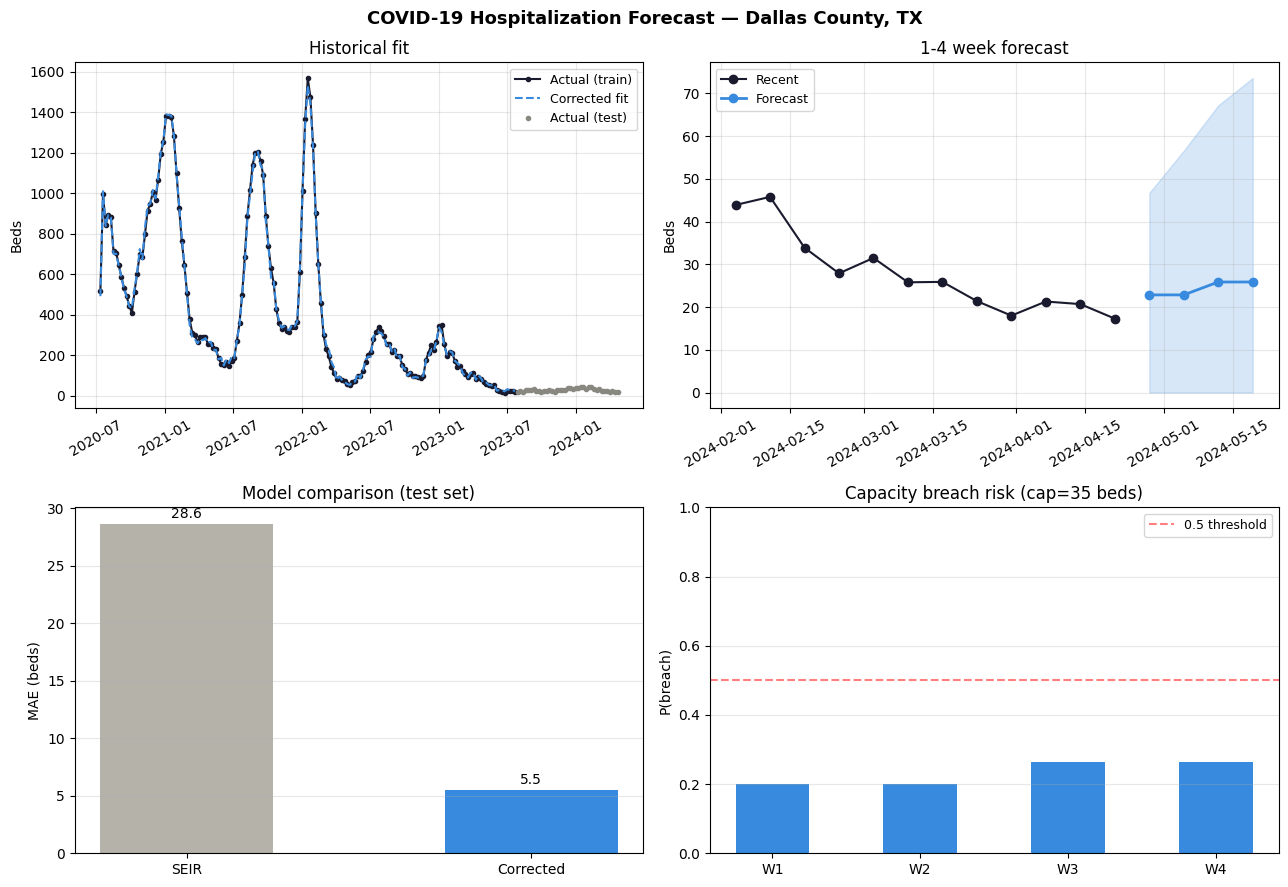


Plot saved as covid_forecast.png


In [108]:
# Plot: Overview
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'COVID-19 Hospitalization Forecast — {TARGET_COUNTY}', fontsize=13, fontweight='bold')

# Plot 1: Historical data and fit
ax = axes[0, 0]
dates_train = weekly_df['date'].values[:n_train]
dates_hold = weekly_df['date'].values[n_train:]
ax.plot(dates_train, y_train, 'o-', color='#1a1a2e', label='Actual (train)', markersize=3)
ax.plot(dates_train, y_corrected_train, '--', color='#378ADD', label='Corrected fit')
if n_hold > 0:
    ax.plot(dates_hold, y_hold, 'o', color='#888780', label='Actual (test)', markersize=3)
ax.set_title('Historical fit')
ax.set_ylabel('Beds')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# Plot 2: 4-week forecast
ax = axes[0, 1]
hist_n = min(12, n_total)
ax.plot(weekly_df['date'].values[-hist_n:], y[-hist_n:], 'o-', color='#1a1a2e', label='Recent')
ax.plot(fc_dates, fc_point, 'o-', color='#378ADD', linewidth=2, label='Forecast')
ax.fill_between(fc_dates, fc_lower, fc_upper, alpha=0.2, color='#378ADD')
ax.set_title('1-4 week forecast')
ax.set_ylabel('Beds')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# Plot 3: MAE comparison
ax = axes[1, 0]
models = ['SEIR', 'Corrected']
maes = [mae_base_hold, mae_corr_hold]
ax.bar(models, maes, color=['#B4B2A9', '#378ADD'], width=0.5)
ax.set_ylabel('MAE (beds)')
ax.set_title('Model comparison (test set)')
ax.grid(axis='y', alpha=0.3)
for i, m in enumerate(maes):
    ax.text(i, m + 0.5, f'{m:.1f}', ha='center')

# Plot 4: Breach probability
ax = axes[1, 1]
weeks = [f'W{i+1}' for i in range(weeks_ahead)]
colors = ['#D85A30' if p > 0.5 else '#378ADD' for p in p_breach]
ax.bar(weeks, p_breach, color=colors, width=0.5)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')
ax.set_ylabel('P(breach)')
ax.set_title(f'Capacity breach risk (cap={HOSPITAL_CAPACITY} beds)')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('covid_forecast.png', dpi=150)
plt.show()

print('\nPlot saved as covid_forecast.png')

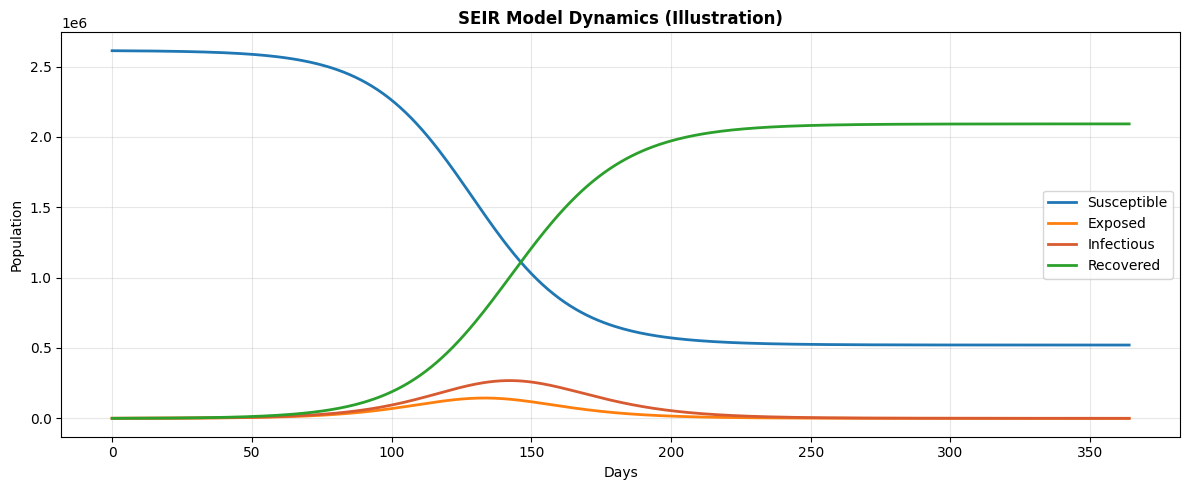

In [109]:
# SEIR dynamics visualization
fig, ax = plt.subplots(figsize=(12, 5))

# Run SEIR with moderate transmission for illustration
beta_demo = 0.2
n_days = 365
S, E, I, R = S0, E0, I0, R0
S_path, E_path, I_path, R_path = [], [], [], []

for _ in range(n_days):
    S, E, I, R = seir_step(S, E, I, R, beta_demo, SIGMA, GAMMA, COUNTY_POPULATION)
    S_path.append(S)
    E_path.append(E)
    I_path.append(I)
    R_path.append(R)

days = np.arange(n_days)
ax.plot(days, S_path, label='Susceptible', linewidth=2)
ax.plot(days, E_path, label='Exposed', linewidth=2)
ax.plot(days, I_path, label='Infectious', linewidth=2, color='#D85A30')
ax.plot(days, R_path, label='Recovered', linewidth=2)

ax.set_title('SEIR Model Dynamics (Illustration)', fontsize=12, fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Population')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

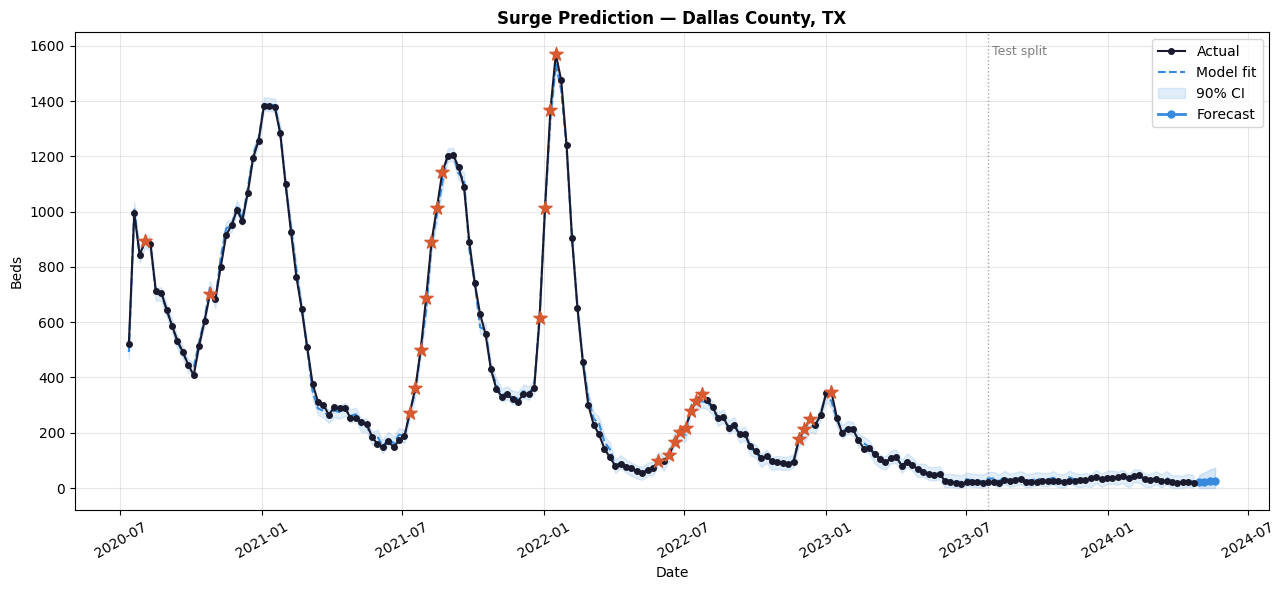

In [110]:
# Surge prediction accuracy
fig, ax = plt.subplots(figsize=(13, 6))

# Plot actual data
ax.plot(weekly_df['date'], y, 'o-', color='#1a1a2e', markersize=4, label='Actual', zorder=3)

# Plot model predictions
pred_all = np.concatenate([y_corrected_train, y_corrected_hold])
pred_dates = weekly_df['date'].values[:len(pred_all)]
ax.plot(pred_dates, pred_all, '--', color='#378ADD', linewidth=1.5, label='Model fit')

# Confidence interval
lower_all = np.concatenate([y_corrected_train - CI_Z * residual_std,
                             y_corrected_hold - CI_Z * residual_std])
upper_all = np.concatenate([y_corrected_train + CI_Z * residual_std,
                             y_corrected_hold + CI_Z * residual_std])
lower_all = np.clip(lower_all, 0, None)
ax.fill_between(pred_dates, lower_all, upper_all, alpha=0.15, color='#378ADD', label='90% CI')

# Forecast
ax.plot(fc_dates, fc_point, 'o-', color='#378ADD', linewidth=2, markersize=5, label='Forecast')
ax.fill_between(fc_dates, fc_lower, fc_upper, alpha=0.2, color='#378ADD')

# Mark train/test split
ax.axvline(weekly_df['date'].values[n_train], color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(weekly_df['date'].values[n_train], ax.get_ylim()[1] * 0.95, ' Test split', fontsize=9, color='gray')

# Mark surges (if any detected)
if surges:
    for s in surges:
        idx = weekly_df[weekly_df['date'].dt.date == s['date']].index
        if len(idx) > 0:
            ax.scatter(s['date'], y[idx[0]], color='#D85A30', s=100, zorder=5, marker='*')

ax.set_title(f'Surge Prediction — {TARGET_COUNTY}', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Beds')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()